In [65]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import sys\n# Add the src folder so the model code can be imported from this notebook.\nsys.path.append("../src")\nfrom GAKELM import GeneticELMRegressor


In [66]:
np.set_printoptions(suppress=True)

In [67]:
sc1 = MinMaxScaler(feature_range = (0, 1)) #use to normalize training data
sc2 = MinMaxScaler(feature_range = (0, 1)) #use to normalize label data

In [68]:
#interpolate function to deal with missing values and outliers
def interpolate_nans(X):
    """Overwrite NaNs with column value interpolations."""
    for j in range(X.shape[1]):
        mask_j = np.isnan(X[:,j])
        X[mask_j,j] = np.interp(np.flatnonzero(mask_j), np.flatnonzero(~mask_j), X[~mask_j,j])
    return X

In [ ]:
# Load and inspect the dataset

dataset = pd.read_csv("../data/Dataset.csv")
dataset.fillna(0, inplace=True)

print("Rows:", dataset.shape[0], "| Columns:", dataset.shape[1])

print("\nDataset Columns:")
print(dataset.columns)

print("\nFirst 5 Rows:")
display(dataset.head())

print("\nDataset Information:")
dataset.info()


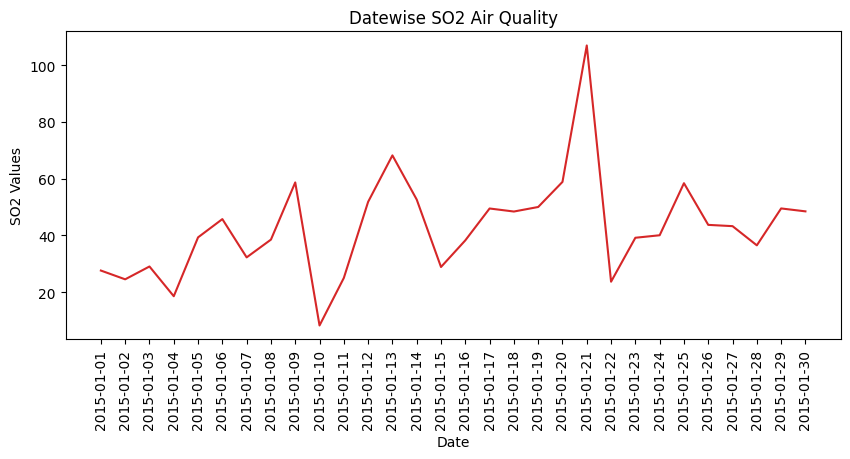

In [70]:
plt.figure(figsize=(10,4), dpi=100)
plt.plot(dataset.Date[0:30], dataset.SO2[0:30], color='tab:red')
plt.gca().set(title="Datewise SO2 Air Quality", xlabel='Date', ylabel="SO2 Values")
plt.xticks(rotation=90)
plt.show()

In [71]:
#dataset preprocessing such as normalization and extracting train and test data from dataset
#extracting X features and Y label from dataset
Y = dataset.values[:,2:3]
dataset.drop(['City'], axis = 1,inplace=True) #removing irrelevant columns
dataset.drop(['Date'], axis = 1,inplace=True)
dataset.drop(['PM2.5'], axis = 1,inplace=True)
dataset.drop(['AQI_Bucket'], axis = 1,inplace=True)
dataset = dataset.values
X = dataset[:,3:dataset.shape[1]-1]

#outlier and missing values removal using interpolation
X = interpolate_nans(X)

X = sc1.fit_transform(X)
Y = sc2.fit_transform(Y)
print("Normalized Training Features")
print(X)

Normalized Training Features
[[0.08532338 0.         0.00633086 ... 0.         0.00012222 0.        ]
 [0.08189055 0.         0.00667492 ... 0.0501499  0.03361036 0.10472222]
 [0.14776119 0.         0.11973576 ... 0.0926683  0.10022    0.0625    ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset  = "+str(X.shape[0]))
print("Total features found in dataset = "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset  = 502
Total features found in dataset = 8
80% dataset for training : 401
20% dataset for testing  : 101


In [73]:
mse = []
rmse = []

In [ ]:
# Calculate MSE and RMSE
def calculateMetrics(algorithm, predict, test_labels):
    predict = np.asarray(predict).ravel()
    test_label = np.asarray(test_labels).ravel()

    # MSE
    mse_value = mean_squared_error(test_label, predict)

    # RMSE
    rmse_value = np.sqrt(mse_value)

    mse.append(mse_value)
    rmse.append(rmse_value)

    print(f'{algorithm} MSE  : {mse_value:.6f}')
    print(f'{algorithm} RMSE : {rmse_value:.6f}')


In [75]:
# Train existing SVR algorithm
svm_cls = SVR()

svm_cls.fit(X_train, y_train.ravel())

predict = svm_cls.predict(X_test)

predict = predict.reshape(-1, 1)

calculateMetrics("SVR", predict, y_test)

SVR MSE  : 0.025847
SVR RMSE : 0.160771


In [76]:
#creating object of genetic EML object by calling class
elm = GeneticELMRegressor()
elm.fit(X_train, y_train)#now train genetic elm on training data
predict = elm.predict(X_test) #perform prediction on test data
calculateMetrics("Propose GA-KELM", predict, y_test)#calculate metrics

Propose GA-KELM MSE  : 0.019424
Propose GA-KELM RMSE : 0.139371


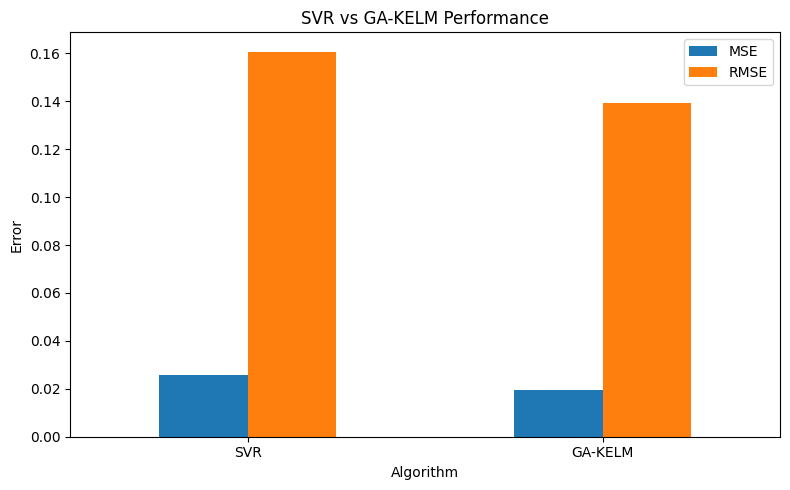

In [77]:
results = pd.DataFrame({
    'Algorithm': ['SVR', 'GA-KELM'],
    'MSE': mse,
    'RMSE': rmse
})
results.set_index('Algorithm')[['MSE', 'RMSE']].plot(kind='bar', figsize=(8, 5))
plt.title('SVR vs GA-KELM Performance')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [78]:
results


,Algorithm,MSE,RMSE
0,SVR,0.025847,0.160771
1,GA-KELM,0.019424,0.139371
